In [3]:
!pip install torch torchview graphviz


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


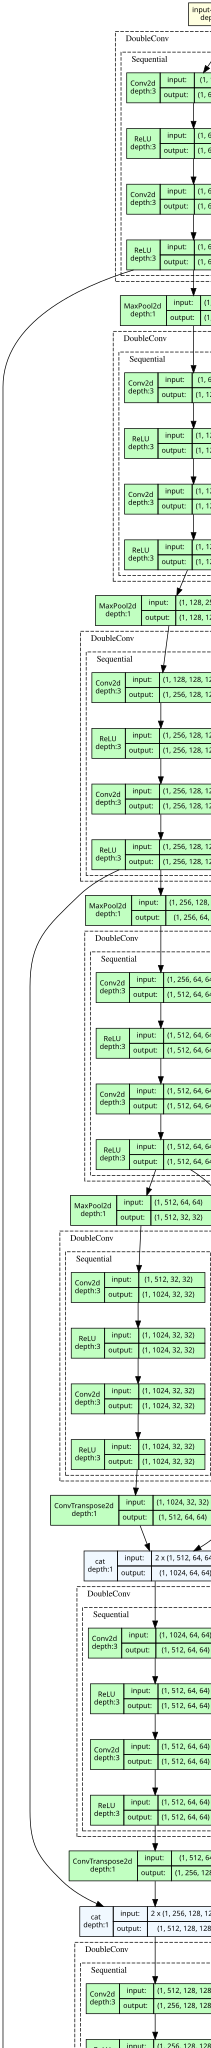

🎉 Схема успешно создана и сохранена в 'unet_architecture.png' и 'unet_architecture.pdf'!


In [4]:
# 1. Установка библиотек (раскомментируйте, если запускаете в новом окружении)
# !pip install torch torchview graphviz

import torch
import torch.nn as nn
from torchview import draw_graph

# ==============================================================================
# 1. ОПИСАНИЕ АРХИТЕКТУРЫ НАШЕЙ МОДЕЛИ
# ==============================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNetDenoising(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Энкодер
        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature))
            current_in = feature

        # Горлышко
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Декодер
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))

        # Выходной слой
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        original_input = x
        skip_connections = []

        # Сжатие
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Восстановление + Skip Connections
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip_conn = skip_connections[i // 2]
            x = self.ups[i + 1](torch.cat((skip_conn, x), dim=1))

        # Global Residual Connection: Вход МИНУС Шум
        predicted_noise = self.final_conv(x)
        cleaned_patch = original_input - predicted_noise
        return cleaned_patch


# ==============================================================================
# 2. ГЕНЕРАЦИЯ БЛОК-СХЕМЫ
# ==============================================================================
model = UNetDenoising(in_channels=1, out_channels=1)

# Строим граф
model_graph = draw_graph(
    model, 
    input_size=(1, 1, 512, 512),       # Входной тензор 512x512
    graph_name="UNet_CT_Denoising", 
    depth=3,                           # Детализация слоев
    expand_nested=True, 
    show_shapes=True,                  # Размеры тензоров
    graph_dir="TB",                    # Сверху вниз
    roll=True
)

# 1. Показываем схему в блокноте
display(model_graph.visual_graph)

# 2. Сохраняем в файлы PNG и PDF
model_graph.visual_graph.render("unet_architecture", format="png")
model_graph.visual_graph.render("unet_architecture", format="pdf")
print("🎉 Схема успешно создана и сохранена в 'unet_architecture.png' и 'unet_architecture.pdf'!")

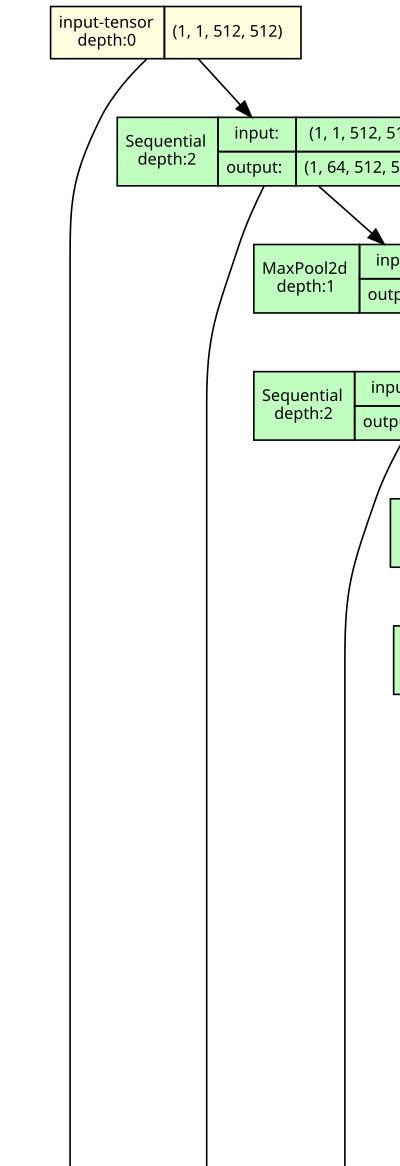

✅ Компактная схема успешно создана!


In [5]:
# ==============================================================================
# КОМПАКТНАЯ БЛОК-СХЕМА (Идеально помещается на экране)
# ==============================================================================
model_graph = draw_graph(
    model, 
    input_size=(1, 1, 512, 512), 
    graph_name="UNet_CT_Denoising", 
    depth=2,               # 🔥 Уменьшаем глубину: DoubleConv станет цельным блоком
    expand_nested=False,   # 🔥 Сворачиваем вложенные слои
    show_shapes=True,      # Оставляем размеры тензоров
    graph_dir="TB",        # Сверху вниз
    roll=True
)

# Отображение компактной схемы в блокноте
display(model_graph.visual_graph)

# Пересохраняем файлы
model_graph.visual_graph.render("unet_architecture_compact", format="png")
model_graph.visual_graph.render("unet_architecture_compact", format="pdf")
print("✅ Компактная схема успешно создана!")

In [2]:
import graphviz

dot = graphviz.Digraph(
    "Restormer_CT_Architecture",
    comment="Guided Restormer for CT Denoising",
    format="png",
)

dot.attr(
    rankdir="TB",
    splines="ortho",
    nodesep="0.4",
    ranksep="0.5",
    fontname="Helvetica",
)
dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Helvetica",
    fontsize="11",
)
dot.attr("edge", fontname="Helvetica", fontsize="9", color="#4A5568")

# --- 1. ВХОДНЫЕ ДАННЫЕ ---
with dot.subgraph(name="cluster_input") as c:
    c.attr(
        label="Входные данные (2 канала)",
        color="#CBD5E1",
        style="dashed,rounded",
    )
    c.node("noisy_in", "Зашумленный срез CT\n[1, H, W]", fillcolor="#FEE2E2")
    c.node("canny_in", "Карта границ Canny\n[1, H, W]", fillcolor="#FEF3C7")
    c.node(
        "cat_in", "Concat (Входной тензор)\n[2, H, W]", fillcolor="#E0E7FF"
    )

dot.node(
    "in_conv",
    "Начальная свертка (Conv 3x3)\nРазмерность C = 48",
    fillcolor="#E2E8F0",
)

# --- 2. ENCODER ---
with dot.subgraph(name="cluster_encoder") as c:
    c.attr(
        label="Энкодер (Извлечение признаков)",
        color="#93C5FD",
        style="rounded",
        bgcolor="#F8FAFC",
    )
    c.node(
        "enc1",
        "Encoder Level 1\nTransformer Blocks (C=48)\n[48, H, W]",
        fillcolor="#DBEAFE",
    )
    c.node(
        "down1",
        "Downsample (Conv 2x2, stride=2)\n[96, H/2, W/2]",
        fillcolor="#BFDBFE",
    )
    c.node(
        "enc2",
        "Encoder Level 2\nTransformer Blocks (C=96)\n[96, H/2, W/2]",
        fillcolor="#DBEAFE",
    )
    c.node(
        "down2",
        "Downsample (Conv 2x2, stride=2)\n[192, H/4, W/4]",
        fillcolor="#BFDBFE",
    )
    c.node(
        "enc3",
        "Encoder Level 3\nTransformer Blocks (C=192)\n[192, H/4, W/4]",
        fillcolor="#DBEAFE",
    )
    c.node(
        "down3",
        "Downsample (Conv 2x2, stride=2)\n[384, H/8, W/8]",
        fillcolor="#BFDBFE",
    )

# --- 3. BOTTLENECK ---
dot.node(
    "bottleneck",
    "Горлышко (Bottleneck)\nTransformer Blocks (C=384)\n[384, H/8, W/8]",
    fillcolor="#DDD6FE",
)

# --- 4. DECODER ---
with dot.subgraph(name="cluster_decoder") as c:
    c.attr(
        label="Декодер (Восстановление разрешения)",
        color="#86EFAC",
        style="rounded",
        bgcolor="#F8FAFC",
    )
    c.node(
        "up3",
        "Upsample (ConvTransposed2d)\n[192, H/4, W/4]",
        fillcolor="#BBF7D0",
    )
    c.node(
        "dec3",
        "Decoder Level 3\nConcat + Conv 1x1 + Transformer\n[192, H/4, W/4]",
        fillcolor="#DCFCE7",
    )
    c.node(
        "up2",
        "Upsample (ConvTransposed2d)\n[96, H/2, W/2]",
        fillcolor="#BBF7D0",
    )
    c.node(
        "dec2",
        "Decoder Level 2\nConcat + Conv 1x1 + Transformer\n[96, H/2, W/2]",
        fillcolor="#DCFCE7",
    )
    c.node(
        "up1", "Upsample (ConvTransposed2d)\n[48, H, W]", fillcolor="#BBF7D0"
    )
    c.node(
        "dec1",
        "Decoder Level 1\nConcat + Conv 1x1 + Transformer\n[48, H, W]",
        fillcolor="#DCFCE7",
    )

# --- 5. ВЫХОДНОЙ БЛОК & GLOBAL RESIDUAL ---
dot.node(
    "out_conv",
    "Финальная свертка (Conv 3x3)\nПрогноз шума [1, H, W]",
    fillcolor="#FED7AA",
)
dot.node(
    "sub_residual",
    "Global Residual (Вычитание)\nЧистый = Noisy - Шум",
    shape="circle",
    fillcolor="#FCA5A5",
)
dot.node(
    "final_clean",
    "Очищенная томограмма (Выход)\n[1, H, W]",
    fillcolor="#86EFAC",
    style="filled,bold",
)

# --- 6. БЛОК ДЕТАЛИЗАЦИИ ТРАНСФОРМЕРА ---
with dot.subgraph(name="cluster_block_detail") as c:
    c.attr(
        label="Анатомия 1 блока Restormer",
        color="#CBD5E1",
        style="dotted,rounded",
    )
    c.node(
        "mdta",
        "MDTA (Multi-Dconv Head Attention)\nКанальное внимание O(C^2)",
        fillcolor="#E0E7FF",
    )
    c.node(
        "gdfn",
        "GDFN (Gated-Dconv FFN)\nGated шлюз с нелинейностью GELU",
        fillcolor="#E0E7FF",
    )
    c.edge("mdta", "gdfn", label="LayerNorm")

# --- СВЯЗИ ОСНОВНОГО ПУТИ ---
dot.edge("noisy_in", "cat_in")
dot.edge("canny_in", "cat_in")
dot.edge("cat_in", "in_conv")
dot.edge("in_conv", "enc1")

# Энкодер
dot.edge("enc1", "down1")
dot.edge("down1", "enc2")
dot.edge("enc2", "down2")
dot.edge("down2", "enc3")
dot.edge("enc3", "down3")
dot.edge("down3", "bottleneck")

# Декодер
dot.edge("bottleneck", "up3")
dot.edge("up3", "dec3")
dot.edge("dec3", "up2")
dot.edge("up2", "dec2")
dot.edge("dec2", "up1")
dot.edge("up1", "dec1")
dot.edge("dec1", "out_conv")

# Skip-Connections (Переброс признаков)
dot.edge(
    "enc3",
    "dec3",
    label="Skip 3",
    style="dashed",
    color="#3B82F6",
    constraint="false",
)
dot.edge(
    "enc2",
    "dec2",
    label="Skip 2",
    style="dashed",
    color="#3B82F6",
    constraint="false",
)
dot.edge(
    "enc1",
    "dec1",
    label="Skip 1",
    style="dashed",
    color="#3B82F6",
    constraint="false",
)

# Вычитание шума
dot.edge("out_conv", "sub_residual", label="Шум (-)")
dot.edge(
    "noisy_in",
    "sub_residual",
    label="Оригинал (+)",
    style="dashed",
    color="#EF4444",
    constraint="false",
)
dot.edge("sub_residual", "final_clean")

# Рендеринг в файл
dot.render("restormer_architecture", view=False)
print("Граф успешно сгенерирован в файл restormer_architecture.png!")

Граф успешно сгенерирован в файл restormer_architecture.png!
